In [5]:
import sys
sys.path.append('/home/artemybombastic/MyGit/KD_Summer_Work/Segmentation')
from Loop import Train_model
from Model import Unet
from torchvision.transforms.functional import adjust_sharpness,adjust_contrast
from Dataset import Eval_Boot_Segmentation_Dataset
import yaml
from PIL import Image
import cv2
from torch.nn import functional as F
from Batching import img2batch,batch2img,img4batch,batch4img
from torch.optim import AdamW
from torch.nn import BCELoss
import torch
from torch import nn
import torch.utils.data as data_utils
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import numpy as np

In [6]:
option_path=fr'/home/artemybombastic/MyGit/KD_Summer_Work/config.yml'
device='cuda' if torch.cuda.is_available() else 'cpu'
device='cpu'
print(device)
with open(option_path,'r') as file_option:
    option=yaml.safe_load(file_option)



cpu


In [7]:
eval_dataset=Eval_Boot_Segmentation_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData/low_boots',option['Segmentation']['label_path'],)
eval_dataloader=DataLoader(dataset=eval_dataset,batch_size=1,drop_last=False,shuffle=False)
#assert dataset.all_items[0].split('/')[-1][:-4]==dataset.all_labels[0].split('/')[-1][:-4]

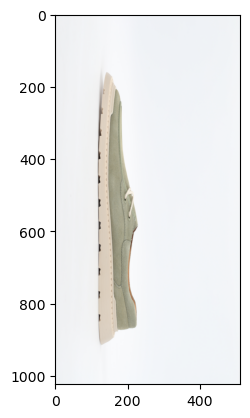

In [15]:
plt.imshow(eval_dataset[0]['img'].permute(1,2,0).detach())